[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BoltMaxwell/sciML_readingGroup/blob/main/neural_ode_tutorial.ipynb)

# Neural ODEs in JAX: from ResNets to continuous normalizing flows

An interactive tour of **Neural Ordinary Differential Equations** built on
[JAX](https://github.com/jax-ml/jax), [Equinox](https://docs.kidger.site/equinox/) (neural nets as pytrees)
and [Diffrax](https://docs.kidger.site/diffrax/) (differentiable ODE solvers).

**What we'll do**

1. **ResNet vs. Neural ODE.** Train both on a 2D spiral-classification task and watch how each one *transports* the data through hidden space. A ResNet takes a fixed number of discrete steps; a Neural ODE takes however many steps the solver decides.
2. **Swap the ODE solver.** A dropdown lets you change the solver (Euler → Dopri8), fixed vs. adaptive steps, and tolerances, and see where the solver actually evaluates the trajectory.
3. **Reverse-mode gradients by hand.** Implement the adjoint method from the original paper in a few lines with `jax.vjp`, watch the adjoint state flow backwards, and see when recomputing the trajectory in reverse goes wrong.
4. **Learn dynamics from data.** Fit a Neural ODE to time series, the most natural use of the model.
5. **Continuous normalizing flows (CNFs).** Use the *instantaneous change of variables* to turn a Neural ODE into a density model, train it on two moons, and slide through time to watch a Gaussian morph into the data.

**Main sources** (linked again where used):

- Chen, Rubanova, Bettencourt, Duvenaud (2018), [*Neural Ordinary Differential Equations*](https://arxiv.org/abs/1806.07366). The paper that introduced Neural ODEs, the adjoint method for training them, and CNFs.
- Kidger (2022), [*On Neural Differential Equations*](https://arxiv.org/abs/2202.02435). A thesis-length tutorial; the best single reference.
- Diffrax examples: [Neural ODE](https://docs.kidger.site/diffrax/examples/neural_ode/) and [Continuous normalising flow](https://docs.kidger.site/diffrax/examples/continuous_normalising_flow/).
- Grathwohl et al. (2018), [*FFJORD*](https://arxiv.org/abs/1810.01367). Scalable CNFs via the Hutchinson trace estimator.

**How to use.** Open in Colab with the badge above, choose *Runtime → Run all*, then scroll through and play with the widgets (dropdowns and sliders re-run the plots). Each section also works on its own after the setup cells. Or run locally from the repo root:
```bash
uv venv --python 3.12 .venv
uv pip install --python .venv/bin/python -r requirements.txt
.venv/bin/jupyter lab neural_ode_tutorial.ipynb
```
The whole notebook runs on CPU in about a minute and a half. The first call to each jitted function compiles it, so expect a pause of a few seconds before the first training step of each section.

In [1]:
#@title Install dependencies (Colab only)
# On Google Colab, install the libraries it does not ship with (JAX itself is preinstalled).
import sys
if "google.colab" in sys.modules:
    %pip install -q diffrax equinox optax

In [2]:
import time
import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import diffrax
import optax
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

# Every transfer in this notebook is a tiny, intentional host->device copy of toy data,
# so silence the (otherwise useful) JAX_TRANSFER_GUARD=log warnings for a clean tutorial.
jax.config.update("jax_transfer_guard", "allow")

plt.rcParams["figure.dpi"] = 110
CLASS_COLORS = np.array(["#1f77b4", "#d62728"])
print(f"jax {jax.__version__} | diffrax {diffrax.__version__} | equinox {eqx.__version__} | devices {jax.devices()}")

jax 0.11.1 | diffrax 0.7.2 | equinox 0.13.8 | devices [CpuDevice(id=0)]


## 1. ResNet vs. Neural ODE

A residual block updates its hidden state as

$$h_{k+1} = h_k + f_k(h_k),$$

which is exactly one **forward-Euler step** of size $\Delta t = 1$ for the ODE $\dot h = f(h)$.
Chen et al. (2018) take this seriously: let the number of layers go to infinity while the step size goes to zero, and the network becomes a *continuous-depth* model

$$\frac{\mathrm{d}h(t)}{\mathrm{d}t} = f_\theta\big(h(t), t\big), \qquad h(0) = x, \qquad \text{output} = h(1),$$

where $h(1)$ is computed by a black-box ODE solver. Two consequences that we will see directly:

- A ResNet with $L$ blocks has $L$ *separate* parameter sets and always takes exactly $L$ steps. A Neural ODE has *one* vector field $f_\theta$ (time-dependence is an input, not a new layer) and the solver chooses the number of steps.
- Because ODE solutions are unique, trajectories of a Neural ODE **cannot cross**: the map $x \mapsto h(1)$ is a homeomorphism. ResNet layers can, in principle, fold space. (This is why nested concentric circles are hard for a plain Neural ODE; see [Augmented Neural ODEs](https://arxiv.org/abs/1904.01681). Interleaved spirals are fine.)

We'll classify two interleaved 2D spirals. Both models push the points around the plane, then a single linear layer reads off the class.

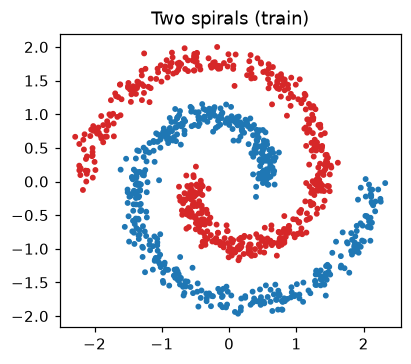

In [3]:
def make_spirals(n_per_class, *, key, noise=0.1, turns=1.0, r0=0.5, r1=2.2):
    k1, k2 = jr.split(key)
    theta = jr.uniform(k1, (n_per_class,)) * 2 * jnp.pi * turns
    r = r0 + (r1 - r0) * theta / (2 * jnp.pi * turns)
    arm = jnp.stack([r * jnp.cos(theta), r * jnp.sin(theta)], axis=-1)
    x = jnp.concatenate([arm, -arm]) + noise * jr.normal(k2, (2 * n_per_class, 2))
    y = jnp.concatenate([jnp.zeros(n_per_class), jnp.ones(n_per_class)])
    return x, y


key = jr.PRNGKey(0)
key, k_train, k_test = jr.split(key, 3)
x_train, y_train = make_spirals(512, key=k_train)
x_test, y_test = make_spirals(256, key=k_test)

plt.figure(figsize=(4, 4))
plt.scatter(*x_train.T, c=CLASS_COLORS[y_train.astype(int)], s=8)
plt.gca().set_aspect("equal"); plt.title("Two spirals (train)"); plt.show()

### The two models

`ResNet` holds a Python list of $L$ independent MLP blocks and steps $h \leftarrow h + \tfrac{1}{L} f_k(h)$ (the $1/L$ keeps the total "time" equal to 1, so the two models are comparable).

`NeuralODE` holds a single MLP $f_\theta(h, t)$ and calls `diffrax.diffeqsolve` to integrate it from $t=0$ to $t=1$. Note that `solve()` takes the solver and step-size controller as arguments; nothing about the *model* depends on how it is integrated.

In [4]:
class ResNet(eqx.Module):
    blocks: list
    head: eqx.nn.Linear

    def __init__(self, n_blocks, width, *, key):
        keys = jr.split(key, n_blocks + 1)
        self.blocks = [
            eqx.nn.MLP(2, 2, width, depth=2, activation=jax.nn.tanh, key=k) for k in keys[:-1]
        ]
        self.head = eqx.nn.Linear(2, 1, key=keys[-1])

    def trajectory(self, x):
        # Returns h_0, h_1, ..., h_L  (shape (L+1, 2)). The Python loop is unrolled under jit.
        dt = 1.0 / len(self.blocks)
        hs = [x]
        for block in self.blocks:
            x = x + dt * block(x)
            hs.append(x)
        return jnp.stack(hs)

    def __call__(self, x):
        return self.head(self.trajectory(x)[-1])[0]  # a logit


class VectorField(eqx.Module):
    # f_theta(h, t): the right-hand side of the ODE. Time is just another input.
    mlp: eqx.nn.MLP

    def __init__(self, width, *, key):
        self.mlp = eqx.nn.MLP(3, 2, width, depth=2, activation=jax.nn.tanh, key=key)

    def __call__(self, t, y, args):
        return self.mlp(jnp.append(y, t))


class NeuralODE(eqx.Module):
    func: VectorField
    head: eqx.nn.Linear

    def __init__(self, width, *, key):
        k1, k2 = jr.split(key)
        self.func = VectorField(width, key=k1)
        self.head = eqx.nn.Linear(2, 1, key=k2)

    def solve(
        self,
        x,
        solver=diffrax.Tsit5(),
        stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),
        dt0=0.1,
        saveat=diffrax.SaveAt(t1=True),
        max_steps=4096,
        adjoint=diffrax.RecursiveCheckpointAdjoint(),
    ):
        return diffrax.diffeqsolve(
            diffrax.ODETerm(self.func), solver, t0=0.0, t1=1.0, dt0=dt0, y0=x,
            saveat=saveat, stepsize_controller=stepsize_controller, max_steps=max_steps, adjoint=adjoint,
        )

    def __call__(self, x):
        return self.head(self.solve(x).ys[-1])[0]

### Training

One generic loop serves both models. Everything that touches arrays is inside a single `eqx.filter_jit`-ed step:
minibatch sampling, the `vmap` over the batch, the loss, and the optimizer update.
`eqx.filter_jit` treats array leaves (weights) as traced and everything else (activation functions, solver objects) as static.
Because the ODE solve is inside the step, the gradient flows *through the solver*; Diffrax's default `RecursiveCheckpointAdjoint` backpropagates through the solver steps with checkpointing.

In [5]:
def train(model, x, y, *, steps, lr=3e-3, batch=128, key, print_every=200):
    optim = optax.adam(lr)
    opt_state = optim.init(eqx.filter(model, eqx.is_inexact_array))

    @eqx.filter_value_and_grad
    def loss_fn(model, xb, yb):
        logits = jax.vmap(model)(xb)
        return jnp.mean(optax.sigmoid_binary_cross_entropy(logits, yb))

    @eqx.filter_jit
    def step(model, opt_state, key):
        idx = jr.choice(key, x.shape[0], (batch,), replace=False)
        loss, grads = loss_fn(model, x[idx], y[idx])
        updates, opt_state = optim.update(grads, opt_state, model)
        return loss, eqx.apply_updates(model, updates), opt_state

    losses = []
    t0 = time.perf_counter()
    for i in range(steps):
        key, sub = jr.split(key)
        loss, model, opt_state = step(model, opt_state, sub)
        losses.append(loss)  # device scalar; no host sync here
        if i % print_every == 0 or i == steps - 1:
            print(f"step {i:4d}  loss {float(loss):.4f}  ({time.perf_counter() - t0:.1f}s)")
    return model, jnp.stack(losses)


@eqx.filter_jit
def accuracy(model, x, y):
    return jnp.mean((jax.vmap(model)(x) > 0) == (y > 0.5))


key, k_res, k_ode, k_tr1, k_tr2 = jr.split(key, 5)
print("ResNet (8 blocks, untied weights)")
resnet, res_losses = train(ResNet(n_blocks=8, width=32, key=k_res), x_train, y_train, steps=800, key=k_tr1)
print("\nNeural ODE (one vector field, Tsit5 adaptive solver)")
node, ode_losses = train(NeuralODE(width=64, key=k_ode), x_train, y_train, steps=800, key=k_tr2)

print(f"\ntest accuracy  ResNet {float(accuracy(resnet, x_test, y_test)):.3f} | Neural ODE {float(accuracy(node, x_test, y_test)):.3f}")
n_params = lambda m: sum(a.size for a in jax.tree_util.tree_leaves(eqx.filter(m, eqx.is_array)))
print(f"parameters     ResNet {n_params(resnet)} | Neural ODE {n_params(node)}")

ResNet (8 blocks, untied weights)


step    0  loss 0.6723  (0.3s)


step  200  loss 0.0042  (0.6s)


step  400  loss 0.0009  (1.0s)


step  600  loss 0.0003  (1.2s)


...

step  200  loss 0.0607  (3.2s)


step  400  loss 0.0037  (5.7s)


step  600  loss 0.0140  (8.2s)


step  799  loss 0.0018  (10.7s)



test accuracy  ResNet 1.000 | Neural ODE 0.996
parameters     ResNet 9747 | Neural ODE 4549


### How each model moves the data

Left: the ResNet's 8 discrete hops $h_0 \to h_1 \to \dots \to h_8$. Right: the Neural ODE's continuous trajectory $h(t)$, sampled at the same 9 times.
Filled dots are inputs, crosses are the final hidden states, and the background is the classifier's decision region.
Notice how the ODE trajectories are smooth curves that never cross, whereas the ResNet's per-layer displacements are free to be jagged.

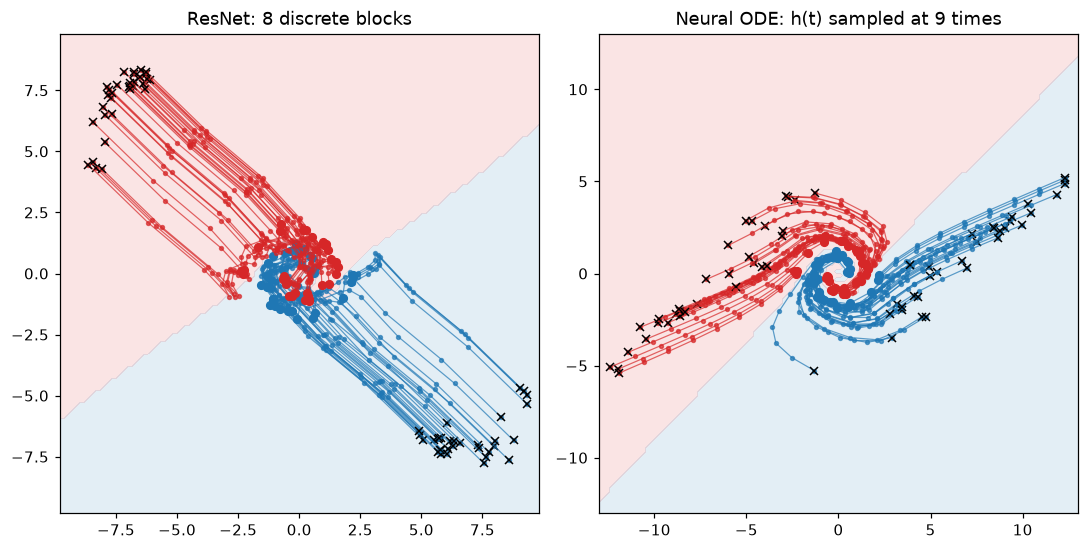

In [6]:
ts_plot = jnp.linspace(0.0, 1.0, 9)
idx_show = jnp.arange(0, x_test.shape[0], 8)  # 64 test points
xs_show, ys_show = x_test[idx_show], y_test[idx_show]

res_traj = jax.vmap(resnet.trajectory)(xs_show)                                      # (N, 9, 2)
ode_traj = jax.vmap(lambda x: node.solve(x, saveat=diffrax.SaveAt(ts=ts_plot)).ys)(xs_show)  # (N, 9, 2)


def plot_trajectories(ax, traj, labels, model, title, marker="o"):
    lim = max(3.2, 1.05 * float(jnp.abs(traj).max()))
    gx, gy = jnp.meshgrid(jnp.linspace(-lim, lim, 120), jnp.linspace(-lim, lim, 120))
    grid = jnp.stack([gx.ravel(), gy.ravel()], -1)
    logits = jax.vmap(model)(grid).reshape(gx.shape)
    ax.contourf(gx, gy, logits > 0, levels=[-0.5, 0.5, 1.5], colors=CLASS_COLORS, alpha=0.12)
    traj = np.asarray(traj)
    for tr, lab in zip(traj, np.asarray(labels).astype(int)):
        ax.plot(tr[:, 0], tr[:, 1], "-", color=CLASS_COLORS[lab], lw=0.8, alpha=0.7)
        ax.plot(tr[:, 0], tr[:, 1], marker, color=CLASS_COLORS[lab], ms=2.5, alpha=0.7)
        ax.plot(tr[0, 0], tr[0, 1], "o", color=CLASS_COLORS[lab], ms=5)
        ax.plot(tr[-1, 0], tr[-1, 1], "x", color="k", ms=5)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal"); ax.set_title(title)


fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_trajectories(axes[0], res_traj, ys_show, resnet, "ResNet: 8 discrete blocks")
plot_trajectories(axes[1], ode_traj, ys_show, node, "Neural ODE: h(t) sampled at 9 times")
plt.tight_layout(); plt.show()

### Interactive: scrub through depth

Drag the slider to see all 256 test points after $k$ ResNet blocks (left) and at the matching time $t = k/8$ of the Neural ODE (right).

In [7]:
res_all = np.asarray(jax.vmap(resnet.trajectory)(x_test))                                              # (256, 9, 2)
ode_all = np.asarray(jax.vmap(lambda x: node.solve(x, saveat=diffrax.SaveAt(ts=ts_plot)).ys)(x_test))  # (256, 9, 2)
lim_depth = 1.05 * max(np.abs(res_all).max(), np.abs(ode_all).max())
colors_test = CLASS_COLORS[np.asarray(y_test).astype(int)]


def show_depth(k=0):
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.6))
    for ax, traj, title in zip(axes, (res_all, ode_all), (f"ResNet after {k} of 8 blocks", f"Neural ODE at t = {k / 8:.3f}")):
        ax.scatter(traj[:, k, 0], traj[:, k, 1], c=colors_test, s=10)
        ax.set_xlim(-lim_depth, lim_depth); ax.set_ylim(-lim_depth, lim_depth); ax.set_aspect("equal"); ax.set_title(title)
    plt.tight_layout(); plt.show()


interact(show_depth, k=widgets.IntSlider(min=0, max=8, value=0, description="depth k", continuous_update=False));

interactive(children=(IntSlider(value=0, continuous_update=False, description='depth k', max=8), Output()), _d…

## 2. Same model, different solvers

The trained `node` defines a vector field; *how* we integrate it is a separate choice. Each Runge–Kutta solver
takes steps $t_n \to t_{n+1}$ and inside each step evaluates $f_\theta$ at several *stages*, so the cost is roughly
$\text{steps} \times \text{stages}$ vector-field evaluations (a bit less for FSAL solvers, which reuse the last stage).

- **Fixed step** (`ConstantStepSize`): the solver lands exactly on $0, \Delta t, 2\Delta t, \dots$ regardless of how hard the dynamics are.
- **Adaptive step** (`PIDController(rtol, atol)`): the solver compares two embedded estimates, shrinks the step where the trajectory bends sharply, and stretches it where the dynamics are gentle. Euler has no error estimate, so it cannot be adaptive.

Below, `SaveAt(steps=True)` records the state at *every accepted step*, so the markers show exactly where the solver evaluated the trajectory.
We measure error against a high-accuracy reference (`Dopri8`, `rtol=1e-8`).

For the full solver list see the [Diffrax solver docs](https://docs.kidger.site/diffrax/api/solvers/ode_solvers/).

In [8]:
SOLVERS = {
    "Euler (order 1)": diffrax.Euler(),
    "Midpoint (order 2)": diffrax.Midpoint(),
    "Heun (order 2)": diffrax.Heun(),
    "Bosh3 (order 3)": diffrax.Bosh3(),
    "Tsit5 (order 5)": diffrax.Tsit5(),
    "Dopri5 (order 5)": diffrax.Dopri5(),
    "Dopri8 (order 8)": diffrax.Dopri8(),
}


def n_stages(solver):
    tab = getattr(solver, "tableau", None)
    return 1 if tab is None else len(tab.b_sol)


@eqx.filter_jit
def solve_all_steps(model, xs, solver, adaptive, dt0, tol):
    # `solver` and `adaptive` are non-array => static under filter_jit (one compile per solver).
    # dt0 and tol are arrays => traced, so changing them does not recompile.
    if adaptive and isinstance(solver, diffrax.AbstractAdaptiveSolver):
        ctrl = diffrax.PIDController(rtol=tol, atol=tol * 1e-3)
    else:
        ctrl = diffrax.ConstantStepSize()
    sol = jax.vmap(
        lambda x: model.solve(
            x, solver=solver, stepsize_controller=ctrl, dt0=dt0,
            saveat=diffrax.SaveAt(t0=True, steps=True), max_steps=4096,
        )
    )(xs)
    # ts/ys are padded with inf beyond the last *accepted* step. Adaptive controllers also
    # reject some steps; those cost vector-field evaluations but are not saved.
    return sol.ts, sol.ys, sol.stats["num_accepted_steps"], sol.stats["num_steps"]


@eqx.filter_jit
def final_states(model, xs, solver, ctrl, dt0):
    return jax.vmap(lambda x: model.solve(x, solver=solver, stepsize_controller=ctrl, dt0=dt0).ys[-1])(xs)


y_ref = final_states(node, x_test, diffrax.Dopri8(), diffrax.PIDController(rtol=1e-8, atol=1e-10), 0.01)


def solver_report(name, adaptive, dt0, tol):
    solver = SOLVERS[name]
    ts, ys, nsteps, nattempts = solve_all_steps(node, x_test, solver, adaptive, jnp.asarray(dt0), jnp.asarray(tol))
    y1 = ys[jnp.arange(ys.shape[0]), nsteps]          # state at the final accepted step
    logits = jax.vmap(node.head)(y1)[:, 0]
    acc = jnp.mean((logits > 0) == (y_test > 0.5))
    err = jnp.linalg.norm(y1 - y_ref, axis=-1)
    return dict(ts=ts, ys=ys, nsteps=nsteps, acc=float(acc), err_mean=float(err.mean()), err_max=float(err.max()),
                mean_steps=float(nsteps.mean()), nfe=float(nattempts.mean()) * n_stages(solver))


print(f"{'solver':<20}{'mode':<10}{'steps':>7}{'~f evals':>10}{'mean err':>10}{'max err':>10}{'test acc':>10}")
for name in SOLVERS:
    for adaptive in (False, True):
        if adaptive and not isinstance(SOLVERS[name], diffrax.AbstractAdaptiveSolver):
            continue
        r = solver_report(name, adaptive, dt0=0.125, tol=1e-3)
        mode = "adaptive" if adaptive else "fixed"
        print(f"{name:<20}{mode:<10}{r['mean_steps']:7.1f}{r['nfe']:10.1f}{r['err_mean']:10.2e}{r['err_max']:10.2e}{r['acc']:10.3f}")

solver              mode        steps  ~f evals  mean err   max err  test acc


Euler (order 1)     fixed         8.0       8.0  6.13e+00  1.47e+01     0.621


Midpoint (order 2)  fixed         8.0      16.0  1.57e+00  8.89e+00     0.934


Midpoint (order 2)  adaptive     99.6     247.6  2.83e-03  2.04e-02     0.996


Heun (order 2)      fixed         8.0      16.0  3.02e+00  1.15e+01     0.852


...

Tsit5 (order 5)     adaptive      5.7      46.9  2.37e-02  3.29e-01     0.996


Dopri5 (order 5)    fixed         8.0      56.0  1.18e-01  1.46e+00     0.996


Dopri5 (order 5)    adaptive      5.0      39.2  7.00e-02  6.72e-01     0.996


Dopri8 (order 8)    fixed         8.0     112.0  3.62e-03  1.05e-01     0.996


Dopri8 (order 8)    adaptive      6.0     102.7  1.60e-03  1.96e-02     0.996


Read the table by rows: Euler with 8 fixed steps *is* an 8-block weight-tied ResNet, and its endpoint error is the largest.
Higher-order solvers reach far lower error for a similar number of vector-field evaluations, and adaptive stepping spends evaluations only where they are needed.
Also note that classification accuracy barely moves: the classifier head is tolerant of small trajectory errors, which is one reason coarse solvers are often "good enough" at test time even when the model was trained with a fine one.

### Interactive: where does the solver evaluate?

Change the solver, toggle adaptive stepping, and adjust the initial step / tolerance. Every marker is an accepted solver step.
(The first time you pick a new solver there is a short compile pause; changing `dt0` or `tol` reuses the compiled function.)

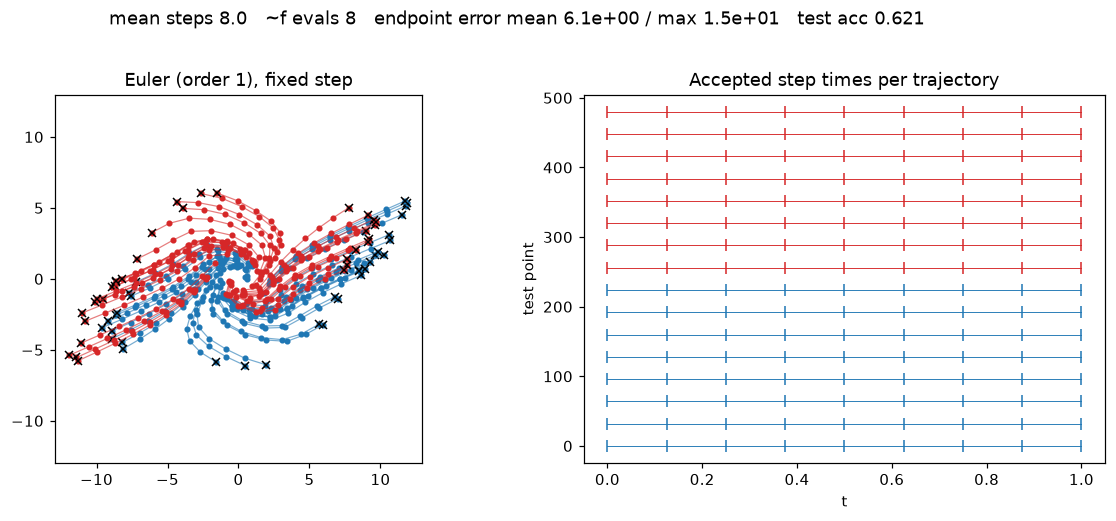

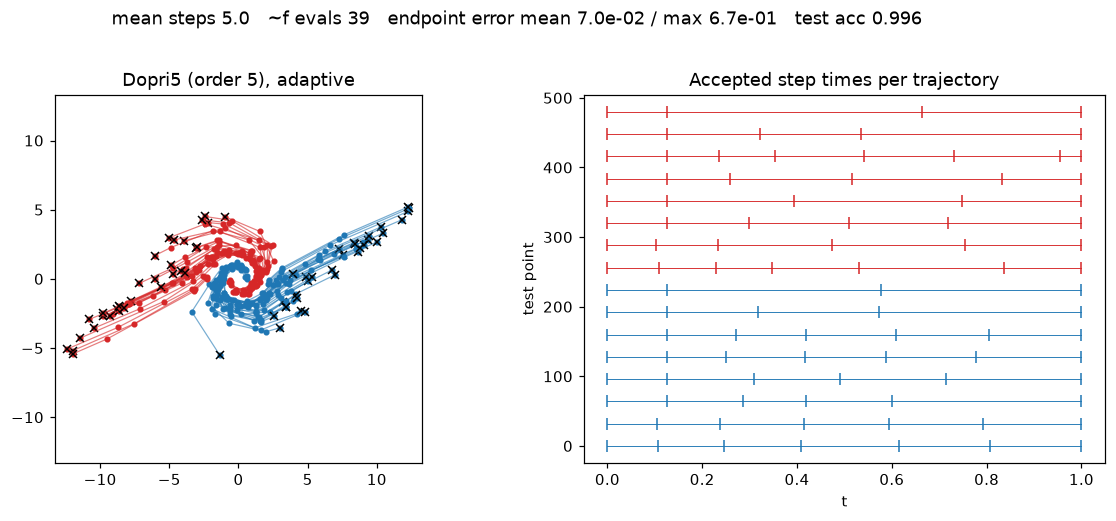

In [9]:
def show_solver(solver="Tsit5 (order 5)", adaptive=True, dt0=0.125, tol=1e-3):
    r = solver_report(solver, adaptive, dt0, tol)
    ts, ys, nsteps = (np.asarray(a) for a in (r["ts"], r["ys"], r["nsteps"]))
    is_adaptive = adaptive and isinstance(SOLVERS[solver], diffrax.AbstractAdaptiveSolver)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), gridspec_kw=dict(width_ratios=[1.15, 1]))
    ax = axes[0]
    for i in np.asarray(idx_show):
        n = nsteps[i] + 1
        c = CLASS_COLORS[int(y_test[i] > 0.5)]
        ax.plot(ys[i, :n, 0], ys[i, :n, 1], "-", color=c, lw=0.8, alpha=0.6)
        ax.plot(ys[i, :n, 0], ys[i, :n, 1], "o", color=c, ms=3)
        ax.plot(ys[i, n - 1, 0], ys[i, n - 1, 1], "x", color="k", ms=5)
    lim = max(3.2, 1.05 * float(np.abs(ys[np.isfinite(ys)]).max()))
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
    ax.set_title(f"{solver}, {'adaptive' if is_adaptive else 'fixed step'}")

    ax = axes[1]
    for i in np.asarray(idx_show)[::4]:
        n = nsteps[i] + 1
        ax.plot(ts[i, :n], np.full(n, i), "|-", ms=8, lw=0.6, color=CLASS_COLORS[int(y_test[i] > 0.5)])
    ax.set_xlabel("t"); ax.set_ylabel("test point"); ax.set_title("Accepted step times per trajectory")

    fig.suptitle(
        f"mean steps {r['mean_steps']:.1f}   ~f evals {r['nfe']:.0f}   "
        f"endpoint error mean {r['err_mean']:.1e} / max {r['err_max']:.1e}   test acc {r['acc']:.3f}", y=1.02
    )
    plt.tight_layout(); plt.show()


show_solver("Euler (order 1)", adaptive=False, dt0=0.125)
show_solver("Dopri5 (order 5)", adaptive=True, dt0=0.125, tol=1e-3)

Now pick your own combination:

In [10]:
interact(
    show_solver,
    solver=widgets.Dropdown(options=list(SOLVERS), value="Tsit5 (order 5)", description="solver"),
    adaptive=widgets.Checkbox(value=True, description="adaptive steps (PID)"),
    dt0=widgets.Dropdown(options=[0.5, 0.25, 0.125, 0.05, 0.02], value=0.125, description="dt0"),
    tol=widgets.Dropdown(options=[1e-1, 1e-2, 1e-3, 1e-5], value=1e-3, description="rtol"),
);

interactive(children=(Dropdown(description='solver', index=4, options=('Euler (order 1)', 'Midpoint (order 2)'…

## 3. Reverse-mode gradients: the adjoint method, by hand

Training needs $\mathrm{d}L/\mathrm{d}\theta$ for a loss $L$ that depends on $h(1)$. Two routes:

- **Backpropagate through the solver.** Record (or checkpoint) every solver step and reverse it. This is ordinary autodiff, exact to floating point, and Diffrax's default (`RecursiveCheckpointAdjoint`). Memory grows with the number of steps.
- **The adjoint method** (Chen et al. 2018, §2; Pontryagin 1962). Define the adjoint state $a(t) = \partial L / \partial h(t)$. It obeys its own ODE, and the parameter gradient is an integral along the trajectory:

$$\frac{\mathrm{d}a}{\mathrm{d}t} = -a(t)^\top \frac{\partial f_\theta}{\partial h}\big(h(t), t\big), \qquad
\frac{\mathrm{d}L}{\mathrm{d}\theta} = \int_0^1 a(t)^\top \frac{\partial f_\theta}{\partial \theta}\big(h(t), t\big)\,\mathrm{d}t .$$

So one backward solve of the **augmented system** $(h, a, g)$ from $t=1$ to $t=0$ does everything:
start from $\big(h(1),\ \partial L/\partial h(1),\ 0\big)$, integrate
$\dot h = f_\theta,\ \dot a = -a^\top \partial_h f_\theta,\ \dot g = -a^\top \partial_\theta f_\theta$, and read off $g(0) = \mathrm{d}L/\mathrm{d}\theta$.
The two vector-Jacobian products are exactly what `jax.vjp` returns, which makes the implementation short.

Memory is $O(1)$ in the number of steps because $h(t)$ is **recomputed** by running the ODE backwards. That is also the catch: if the dynamics are unstable in reverse, the recomputed $h(t)$ drifts away from the forward trajectory and the gradient degrades. The `"interpolate"` mode below instead reads $h(t)$ from the stored forward solution (`SaveAt(dense=True)`), trading memory for accuracy.

In [11]:
def loss_from_h1(head, h1, y):
    return optax.sigmoid_binary_cross_entropy(head(h1)[0], y)


neg = lambda tree: jax.tree_util.tree_map(lambda g: -g, tree)
flat = lambda tree: jnp.concatenate([g.ravel() for g in jax.tree_util.tree_leaves(tree)])


@eqx.filter_jit
def adjoint_method(model, x, y, mode, rtol, atol, ts_save):
    params, static = eqx.partition(model.func, eqx.is_array)
    f = lambda t, h, p: eqx.combine(p, static)(t, h, None)   # f_theta with theta as an explicit argument
    ctrl = diffrax.PIDController(rtol=rtol, atol=atol)

    # 1. forward solve; the dense interpolant is only used by the "interpolate" mode
    fwd = diffrax.diffeqsolve(
        diffrax.ODETerm(f), diffrax.Tsit5(), 0.0, 1.0, 0.1, x, args=params,
        stepsize_controller=ctrl, saveat=diffrax.SaveAt(t1=True, dense=True),
    )
    h1 = fwd.ys[-1]

    # 2. adjoint at t = 1 is the ordinary gradient of the loss w.r.t. the final state
    a1 = jax.grad(loss_from_h1, argnums=1)(model.head, h1, y)

    # 3. augmented dynamics for (h, a, dL/dtheta), integrated backwards in time
    def augmented(t, state, args):
        h, a, _ = state
        if mode == "interpolate":
            h = fwd.evaluate(t)
        f_val, vjp = jax.vjp(lambda h, p: f(t, h, p), h, params)
        a_dfdh, a_dfdtheta = vjp(a)          # a^T df/dh  and  a^T df/dtheta
        return f_val, -a_dfdh, neg(a_dfdtheta)

    g0 = jax.tree_util.tree_map(jnp.zeros_like, params)
    bwd = diffrax.diffeqsolve(
        diffrax.ODETerm(augmented), diffrax.Tsit5(), 1.0, 0.0, -0.1, (h1, a1, g0),
        stepsize_controller=ctrl, saveat=diffrax.SaveAt(ts=ts_save),
    )
    hs, adjoints, grads = bwd.ys
    return hs, adjoints, jax.tree_util.tree_map(lambda g: g[-1], grads), bwd.stats["num_steps"]


@eqx.filter_jit
def reference_grad(model, x, y):
    # Autodiff through a very accurate solve: our "ground truth" dL/dtheta.
    def loss(func):
        m = eqx.tree_at(lambda m: m.func, model, func)
        h1 = m.solve(x, solver=diffrax.Dopri8(), stepsize_controller=diffrax.PIDController(rtol=1e-8, atol=1e-10), dt0=0.01).ys[-1]
        return loss_from_h1(m.head, h1, y)
    return flat(eqx.filter(eqx.filter_grad(loss)(model.func), eqx.is_array))


ts_back = jnp.linspace(1.0, 0.0, 41)
i_pt = 8
x_pt, y_pt = x_test[i_pt], y_test[i_pt]
g_ref = reference_grad(node, x_pt, y_pt)

print(f"{'mode':<13}{'rtol':>8}{'bwd steps':>11}{'h(0) recon err':>16}{'grad rel err':>14}")
for mode in ("recompute", "interpolate"):
    for rtol in (1e-2, 1e-3, 1e-5):
        hs, adj, g, n = adjoint_method(node, x_pt, y_pt, mode, rtol, rtol * 1e-3, ts_back)
        rel = jnp.linalg.norm(flat(g) - g_ref) / jnp.linalg.norm(g_ref)
        print(f"{mode:<13}{rtol:>8.0e}{int(n):>11}{float(jnp.linalg.norm(hs[-1] - x_pt)):>16.2e}{float(rel):>14.2e}")

mode             rtol  bwd steps  h(0) recon err  grad rel err


recompute       1e-02          2        1.57e+00      1.87e+00


recompute       1e-03          9        3.93e-02      1.65e-01


recompute       1e-05         16        9.31e-05      3.63e-03


interpolate     1e-02          2        2.67e-01      4.02e+00


interpolate     1e-03          9        2.13e-02      1.17e-01


interpolate     1e-05         16        3.14e-04      2.39e-03


The "h(0) recon err" column is how far the backward-recomputed trajectory lands from the true starting point $x$. In `recompute` mode this error feeds straight into the gradient; in `interpolate` mode the adjoint always sees the true trajectory (the column is then only a diagnostic), but the adjoint ODE itself is still solved at the chosen tolerance. Both converge to the reference as the tolerance tightens.

### Interactive: watch the adjoint flow backwards

Left: the forward trajectory $h(t)$ (solid), the trajectory recomputed backwards by the adjoint solve (dashed), and the adjoint vector $a(t)$ drawn as arrows along the path. Right: the components of $a(t)$. Try `recompute` at loose tolerance on different points to find where the reverse dynamics drift.

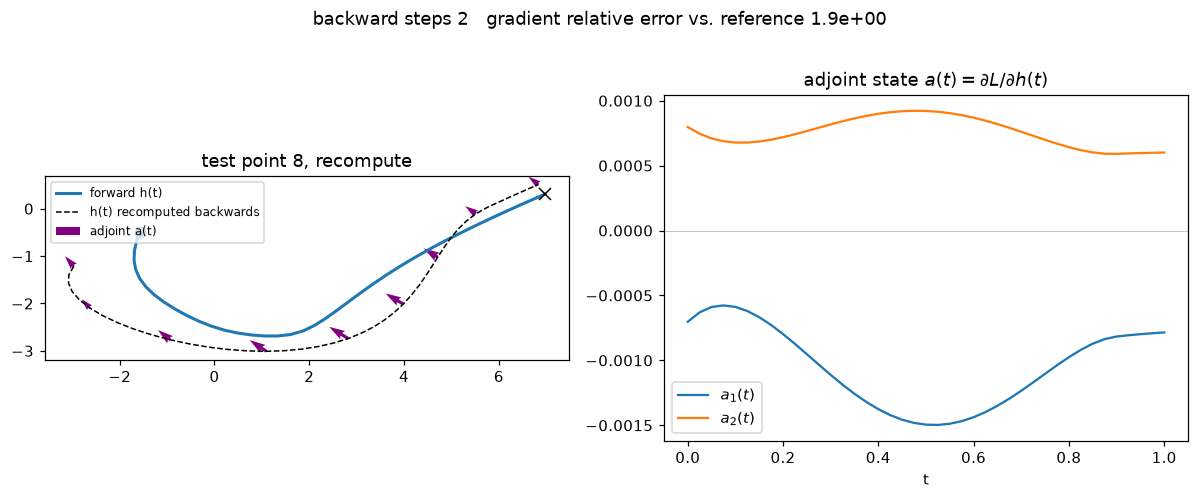

In [12]:
ts_fwd = jnp.linspace(0.0, 1.0, 41)


def show_adjoint(point=8, mode="recompute", rtol=1e-3):
    x, y = x_test[point], y_test[point]
    hs, adj, g, n = adjoint_method(node, x, y, mode, rtol, rtol * 1e-3, ts_back)
    rel = float(jnp.linalg.norm(flat(g) - reference_grad(node, x, y)) / jnp.linalg.norm(reference_grad(node, x, y)))
    fwd_path = node.solve(x, solver=diffrax.Dopri8(), stepsize_controller=diffrax.PIDController(rtol=1e-8, atol=1e-10),
                          dt0=0.01, saveat=diffrax.SaveAt(ts=ts_fwd)).ys
    hs, adj, fwd_path = np.asarray(hs)[::-1], np.asarray(adj)[::-1], np.asarray(fwd_path)  # reorder to increasing t
    c = CLASS_COLORS[int(y > 0.5)]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
    ax = axes[0]
    ax.plot(fwd_path[:, 0], fwd_path[:, 1], "-", color=c, lw=2, label="forward h(t)")
    ax.plot(hs[:, 0], hs[:, 1], "--", color="k", lw=1, label="h(t) recomputed backwards")
    sl = slice(0, None, 5)
    ax.quiver(hs[sl, 0], hs[sl, 1], adj[sl, 0], adj[sl, 1], color="purple", angles="xy", scale_units="xy",
              scale=float(np.abs(adj).max()) * 2.5, width=0.006, label="adjoint a(t)")
    ax.plot(x[0], x[1], "o", color=c, ms=7); ax.plot(fwd_path[-1, 0], fwd_path[-1, 1], "x", color="k", ms=8)
    ax.set_aspect("equal"); ax.legend(loc="upper left", fontsize=8); ax.set_title(f"test point {point}, {mode}")

    ax = axes[1]
    ax.plot(ts_fwd, adj[:, 0], label="$a_1(t)$"); ax.plot(ts_fwd, adj[:, 1], label="$a_2(t)$")
    ax.axhline(0, color="0.7", lw=0.5); ax.set_xlabel("t"); ax.legend(); ax.set_title("adjoint state $a(t) = \\partial L / \\partial h(t)$")
    fig.suptitle(f"backward steps {int(n)}   gradient relative error vs. reference {rel:.1e}", y=1.02)
    plt.tight_layout(); plt.show()


show_adjoint(point=8, mode="recompute", rtol=1e-2)

Choose your own point, mode and tolerance:

In [13]:
interact(
    show_adjoint,
    point=widgets.Dropdown(options=[int(i) for i in np.asarray(idx_show)[:16]], value=8, description="test point"),
    mode=widgets.Dropdown(options=["recompute", "interpolate"], value="recompute", description="mode"),
    rtol=widgets.Dropdown(options=[1e-1, 1e-2, 1e-3, 1e-5], value=1e-2, description="rtol"),
);

interactive(children=(Dropdown(description='test point', index=1, options=(0, 8, 16, 24, 32, 40, 48, 56, 64, 7…

### Diffrax's built-in options

You never have to write this yourself. `diffeqsolve(..., adjoint=...)` accepts `RecursiveCheckpointAdjoint` (backprop through the solver, the default), `BacksolveAdjoint` (the recompute-backwards method above), `DirectAdjoint` and `ForwardMode`. Below we compare the first two on a batch of test points at two tolerances; see Kidger's thesis, [§5.1](https://arxiv.org/abs/2202.02435), for a fuller discussion of when each is appropriate.

In [14]:
@eqx.filter_jit
def batch_grad(model, adjoint, rtol, atol, xs, ys):
    def loss(func):
        m = eqx.tree_at(lambda m: m.func, model, func)
        h1 = jax.vmap(lambda x: m.solve(x, stepsize_controller=diffrax.PIDController(rtol=rtol, atol=atol), adjoint=adjoint).ys[-1])(xs)
        return jnp.mean(jax.vmap(loss_from_h1, in_axes=(None, 0, 0))(m.head, h1, ys))
    return flat(eqx.filter(eqx.filter_grad(loss)(model.func), eqx.is_array))


xs_b, ys_b = x_test[:32], y_test[:32]
for rtol in (1e-3, 1e-6):
    g_ckpt = batch_grad(node, diffrax.RecursiveCheckpointAdjoint(), rtol, rtol * 1e-3, xs_b, ys_b)
    g_back = batch_grad(node, diffrax.BacksolveAdjoint(), rtol, rtol * 1e-3, xs_b, ys_b)
    print(f"rtol {rtol:.0e}: relative difference between checkpoint and backsolve gradients {float(jnp.linalg.norm(g_ckpt - g_back) / jnp.linalg.norm(g_ckpt)):.2e}")

rtol 1e-03: relative difference between checkpoint and backsolve gradients 4.70e-01


rtol 1e-06: relative difference between checkpoint and backsolve gradients 1.82e-04


## 4. Learning dynamics from time series

Classification hides the most natural use of a Neural ODE: **learning a dynamical system from observed trajectories**.
This section is a condensed version of the [Diffrax Neural ODE example](https://docs.kidger.site/diffrax/examples/neural_ode/).
The data are trajectories of the nonlinear oscillator

$$\dot y = \Big(\tfrac{y_2}{1+y_2},\; -\tfrac{y_1}{1+y_1}\Big),$$

and the model is a Neural ODE $\dot y = f_\theta(y)$ trained to reproduce them from the initial condition alone.
Two practical tricks from that example: train first on a short prefix of each trajectory (an easier problem, and a good initialization) and use `SaveAt(ts=...)` to evaluate the solution at the observation times.

prefix  10%  step   0  loss 0.10810  (2.2s)


prefix  10%  step 100  loss 0.00658  (2.5s)


prefix  10%  step 200  loss 0.01623  (2.8s)


prefix  10%  step 299  loss 0.00581  (3.1s)


prefix 100%  step   0  loss 0.04330  (2.3s)


prefix 100%  step 100  loss 0.04317  (3.8s)


prefix 100%  step 200  loss 0.02510  (5.4s)


prefix 100%  step 300  loss 0.02693  (6.9s)


prefix 100%  step 400  loss 0.04344  (8.5s)


prefix 100%  step 499  loss 0.03777  (10.1s)


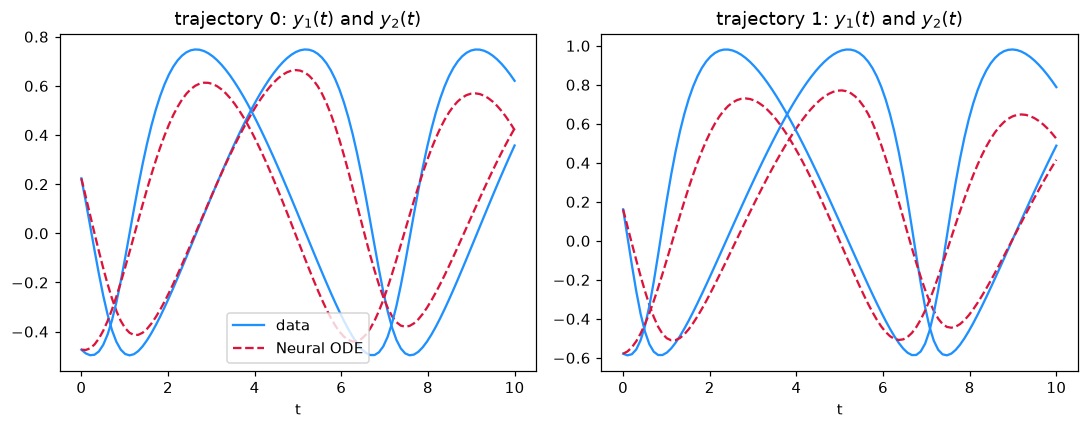

In [15]:
def true_dynamics(t, y, args):
    x = y / (1 + y)
    return jnp.stack([x[1], -x[0]])


def make_trajectories(n, ts, *, key):
    def one(k):
        y0 = jr.uniform(k, (2,), minval=-0.6, maxval=1.0)
        return diffrax.diffeqsolve(
            diffrax.ODETerm(true_dynamics), diffrax.Tsit5(), ts[0], ts[-1], 0.1, y0,
            saveat=diffrax.SaveAt(ts=ts),
        ).ys
    return jax.vmap(one)(jr.split(key, n))


class DynamicsField(eqx.Module):
    mlp: eqx.nn.MLP

    def __init__(self, width, depth, *, key):
        self.mlp = eqx.nn.MLP(2, 2, width, depth, activation=jax.nn.softplus, final_activation=jax.nn.tanh, key=key)

    def __call__(self, t, y, args):
        return self.mlp(y)


class DynamicsODE(eqx.Module):
    func: DynamicsField

    def __init__(self, width=64, depth=2, *, key):
        self.func = DynamicsField(width, depth, key=key)

    def __call__(self, ts, y0, rtol=1e-3, atol=1e-6):
        return diffrax.diffeqsolve(
            diffrax.ODETerm(self.func), diffrax.Tsit5(), ts[0], ts[-1], ts[1] - ts[0], y0,
            stepsize_controller=diffrax.PIDController(rtol=rtol, atol=atol),
            saveat=diffrax.SaveAt(ts=ts),
        ).ys


key, k_data, k_model, k_tr = jr.split(key, 4)
ts_obs = jnp.linspace(0, 10, 100)
ys_obs = make_trajectories(256, ts_obs, key=k_data)  # (256, 100, 2)
dyn = DynamicsODE(key=k_model)
optim = optax.adabelief(3e-3)


@eqx.filter_jit
def dyn_step(model, opt_state, ts, ys_batch):
    def loss_fn(model):
        pred = jax.vmap(model, in_axes=(None, 0))(ts, ys_batch[:, 0])
        return jnp.mean((ys_batch - pred) ** 2)
    loss, grads = eqx.filter_value_and_grad(loss_fn)(model)
    updates, opt_state = optim.update(grads, opt_state, model)
    return loss, eqx.apply_updates(model, updates), opt_state


for n_steps, frac in [(300, 0.1), (500, 1.0)]:  # short prefix first, then full trajectories
    opt_state = optim.init(eqx.filter(dyn, eqx.is_inexact_array))
    T = int(ts_obs.shape[0] * frac)
    t0 = time.perf_counter()
    for i in range(n_steps):
        key, sub = jr.split(key)
        batch = ys_obs[jr.choice(sub, ys_obs.shape[0], (32,), replace=False), :T]
        loss, dyn, opt_state = dyn_step(dyn, opt_state, ts_obs[:T], batch)
        if i % 100 == 0 or i == n_steps - 1:
            print(f"prefix {frac:>4.0%}  step {i:3d}  loss {float(loss):.5f}  ({time.perf_counter() - t0:.1f}s)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for k, ax in enumerate(axes):
    pred = dyn(ts_obs, ys_obs[k, 0])
    for j, lab in enumerate(["data", None]):
        ax.plot(ts_obs, ys_obs[k, :, j], color="dodgerblue", label=lab)
        ax.plot(ts_obs, pred[:, j], "--", color="crimson", label=None if lab is None else "Neural ODE")
    ax.set_xlabel("t"); ax.set_title(f"trajectory {k}: $y_1(t)$ and $y_2(t)$")
axes[0].legend(); plt.tight_layout(); plt.show()

### Interactive: start the learned system anywhere

The model only ever saw trajectories started in $[-0.6, 1]^2$. Move the initial condition around, then push it slightly outside that box and watch the learned dynamics (dashed) drift from the truth (solid). Neural ODEs interpolate well and extrapolate like any other neural network.

In [16]:
@eqx.filter_jit
def true_and_learned(model, y0, ts):
    true = diffrax.diffeqsolve(
        diffrax.ODETerm(true_dynamics), diffrax.Tsit5(), ts[0], ts[-1], 0.1, y0, saveat=diffrax.SaveAt(ts=ts)
    ).ys
    return true, model(ts, y0)


def show_dynamics(y1=0.5, y2=-0.3):
    true, pred = (np.asarray(a) for a in true_and_learned(dyn, jnp.array([y1, y2]), ts_obs))
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw=dict(width_ratios=[1.4, 1]))
    ax = axes[0]
    ax.plot(ts_obs, true[:, 0], color="dodgerblue", label="true"); ax.plot(ts_obs, true[:, 1], color="dodgerblue")
    ax.plot(ts_obs, pred[:, 0], "--", color="crimson", label="Neural ODE"); ax.plot(ts_obs, pred[:, 1], "--", color="crimson")
    ax.set_xlabel("t"); ax.legend(); ax.set_title(f"y(0) = ({y1:.2f}, {y2:.2f})")
    ax = axes[1]
    ax.plot(true[:, 0], true[:, 1], color="dodgerblue"); ax.plot(pred[:, 0], pred[:, 1], "--", color="crimson")
    ax.plot(y1, y2, "ko"); ax.add_patch(plt.Rectangle((-0.6, -0.6), 1.6, 1.6, fill=False, ls=":", color="0.5"))
    ax.set_xlabel("$y_1$"); ax.set_ylabel("$y_2$"); ax.set_aspect("equal"); ax.set_title("phase plane (dotted box = training range)")
    plt.tight_layout(); plt.show()


interact(
    show_dynamics,
    y1=widgets.FloatSlider(min=-0.7, max=1.4, step=0.05, value=0.5, description="y1(0)", continuous_update=False),
    y2=widgets.FloatSlider(min=-0.7, max=1.4, step=0.05, value=-0.3, description="y2(0)", continuous_update=False),
);

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='y1(0)', max=1.4, min=-0.7, …

## 5. Continuous normalizing flows

A normalizing flow models a density by pushing a simple base distribution $p_0 = \mathcal N(0, I)$ through an invertible map. Discrete flows need layers whose Jacobian determinant is cheap. A **continuous normalizing flow** (Chen et al. 2018, §4) instead lets the map be the flow of an ODE, $z(0) \sim p_0$, $\dot z = f_\theta(z, t)$, and uses the *instantaneous change of variables*:

$$\frac{\partial \log p\big(z(t)\big)}{\partial t} = -\operatorname{tr}\!\left(\frac{\partial f_\theta}{\partial z}\right).$$

Only a **trace** is needed, not a determinant, and the map is invertible for free (run the ODE backwards).
To evaluate $\log p_1(x)$ for a data point $x$, integrate the augmented state $(z, \ell)$ **from $t=1$ back to $t=0$** with $\ell(1) = 0$, $\dot\ell = -\operatorname{tr}(\partial f_\theta / \partial z)$. Then $\ell(0) = \int_0^1 \operatorname{tr}(\partial f_\theta/\partial z)\,\mathrm{d}t$ and

$$\log p_1(x) = \log p_0\big(z(0)\big) - \ell(0).$$

Training maximizes this likelihood on data. Sampling integrates *forwards* from Gaussian noise. To keep training fast we integrate with a fixed-step Midpoint solver (20 steps) during training and switch to adaptive Dopri5 for evaluation, a common trick: the vector field is the model, the solver is a choice.

In 2D we compute the trace exactly with `jax.jacfwd` (two JVPs). In high dimensions [FFJORD](https://arxiv.org/abs/1810.01367) uses Hutchinson's estimator $\operatorname{tr}(J) = \mathbb E_\epsilon[\epsilon^\top J \epsilon]$ with a single JVP; we demonstrate it at the end.
Compare the [Diffrax CNF example](https://docs.kidger.site/diffrax/examples/continuous_normalising_flow/) and the [pyprobml two-moons CNF notebook](https://github.com/probml/pyprobml/blob/master/notebooks/book2/23/two_moons_cnf_normalizing_flow.ipynb).

In [17]:
def make_moons(n, *, key, noise=0.08):
    k1, k2, k3 = jr.split(key, 3)
    t = jr.uniform(k1, (n,)) * jnp.pi
    upper = jnp.stack([jnp.cos(t), jnp.sin(t)], -1)
    lower = jnp.stack([1 - jnp.cos(t), 0.5 - jnp.sin(t)], -1)
    x = jnp.where(jr.bernoulli(k2, 0.5, (n, 1)), upper, lower) + noise * jr.normal(k3, (n, 2))
    return (x - jnp.array([0.5, 0.25])) * 1.6


def log_normal(z):
    return -0.5 * jnp.sum(z**2) - z.shape[-1] * 0.5 * jnp.log(2 * jnp.pi)


class CNFField(eqx.Module):
    mlp: eqx.nn.MLP

    def __init__(self, width, depth, *, key):
        self.mlp = eqx.nn.MLP(3, 2, width, depth, activation=jax.nn.tanh, key=key)

    def __call__(self, t, y, args):
        return self.mlp(jnp.append(y, t))


class CNF(eqx.Module):
    func: CNFField

    def __init__(self, width=64, depth=3, *, key):
        self.func = CNFField(width, depth, key=key)

    def augmented(self, t, state, args):
        y, _ = state
        dy = self.func(t, y, args)
        trace = jnp.trace(jax.jacfwd(lambda y: self.func(t, y, args))(y))  # exact, cheap in 2D
        return dy, -trace

    def log_prob(self, x, solver=diffrax.Dopri5(), stepsize_controller=diffrax.PIDController(rtol=1e-4, atol=1e-6), dt0=-0.05):
        sol = diffrax.diffeqsolve(
            diffrax.ODETerm(self.augmented), solver, t0=1.0, t1=0.0, dt0=dt0,
            y0=(x, jnp.zeros(())), stepsize_controller=stepsize_controller,
        )
        z0, ell = sol.ys[0][-1], sol.ys[1][-1]
        return log_normal(z0) - ell

    def flow(self, z0, ts):
        # Push base samples forward in time; returns z(t) at each t in ts.
        return diffrax.diffeqsolve(
            diffrax.ODETerm(self.func), diffrax.Dopri5(), t0=0.0, t1=1.0, dt0=0.05, y0=z0,
            stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-5), saveat=diffrax.SaveAt(ts=ts),
        ).ys


key, k_moons, k_cnf, k_tr = jr.split(key, 4)
x_moons = make_moons(4096, key=k_moons)
cnf = CNF(key=k_cnf)
cnf_optim = optax.adam(optax.warmup_cosine_decay_schedule(0.0, 3e-3, 50, 500, 1e-4))
cnf_opt_state = cnf_optim.init(eqx.filter(cnf, eqx.is_inexact_array))


@eqx.filter_jit
def cnf_step(model, opt_state, key):
    xb = x_moons[jr.choice(key, x_moons.shape[0], (128,), replace=False)]
    # Train with a cheap fixed-step solver (Midpoint, 20 steps); evaluate later with an adaptive one.
    def loss(m):
        log_p = jax.vmap(lambda x: m.log_prob(x, diffrax.Midpoint(), diffrax.ConstantStepSize(), -0.05))(xb)
        return -jnp.mean(log_p)
    nll, grads = eqx.filter_value_and_grad(loss)(model)
    updates, opt_state = cnf_optim.update(grads, opt_state, model)
    return nll, eqx.apply_updates(model, updates), opt_state


t0 = time.perf_counter()
for i in range(500):
    key, sub = jr.split(key)
    nll, cnf, cnf_opt_state = cnf_step(cnf, cnf_opt_state, sub)
    if i % 100 == 0 or i == 499:
        print(f"step {i:4d}  NLL {float(nll):.4f}  ({time.perf_counter() - t0:.1f}s)")

step    0  NLL 3.1055  (1.9s)


step  100  NLL 2.3174  (5.7s)


step  200  NLL 2.1298  (9.5s)


step  300  NLL 1.9460  (13.2s)


step  400  NLL 1.9937  (16.9s)


step  499  NLL 1.8302  (20.5s)


### Learned density and samples

Left: the data. Middle: $p_1(x)$ evaluated on a grid via `log_prob` with the adaptive solver (each grid point is a backward ODE solve, batched with `vmap`). Right: samples obtained by integrating Gaussian noise forwards.

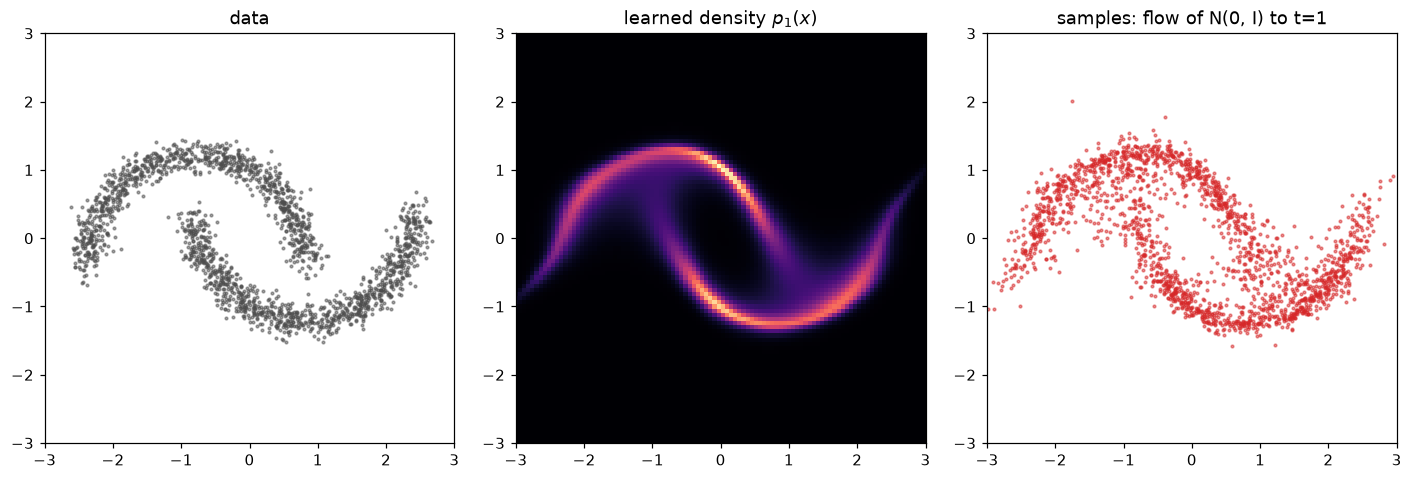

In [18]:
lim = 3.0
gx, gy = jnp.meshgrid(jnp.linspace(-lim, lim, 100), jnp.linspace(-lim, lim, 100))
grid = jnp.stack([gx.ravel(), gy.ravel()], -1)
@eqx.filter_jit
def batched_log_prob(model, xs):
    return jax.vmap(model.log_prob)(xs)


@eqx.filter_jit
def batched_flow(model, z0, ts):
    return jax.vmap(model.flow, in_axes=(0, None))(z0, ts)


density = jnp.exp(batched_log_prob(cnf, grid)).reshape(gx.shape)

key, k_z = jr.split(key)
ts_flow = jnp.linspace(0.0, 1.0, 21)
z0 = jr.normal(k_z, (2000, 2))
paths = batched_flow(cnf, z0, ts_flow)  # (2000, 21, 2)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
axes[0].scatter(*x_moons[:2000].T, s=3, alpha=0.5, color="0.3"); axes[0].set_title("data")
axes[1].pcolormesh(gx, gy, density, cmap="magma", shading="auto"); axes[1].set_title("learned density $p_1(x)$")
axes[2].scatter(*paths[:, -1].T, s=3, alpha=0.5, color="#d62728"); axes[2].set_title("samples: flow of N(0, I) to t=1")
for ax in axes:
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

### Interactive: watch the Gaussian become two moons

Drag the slider to move along $t \in [0, 1]$. Each point is one base sample $z(0) \sim \mathcal N(0,I)$ carried along its ODE trajectory, colored by its initial angle so you can follow individual points.

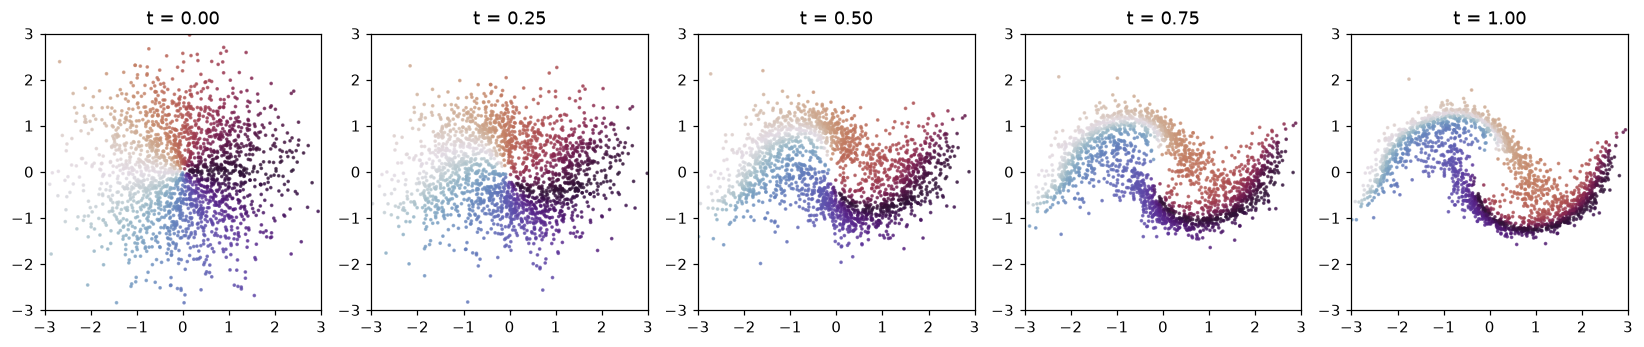

interactive(children=(IntSlider(value=0, continuous_update=False, description='time', max=20), Output()), _dom…

In [19]:
paths_np = np.asarray(paths)
hue = (np.arctan2(z0[:, 1], z0[:, 0]) + np.pi) / (2 * np.pi)


def show_flow(t_index=0):
    plt.figure(figsize=(4.8, 4.8))
    plt.scatter(paths_np[:, t_index, 0], paths_np[:, t_index, 1], c=hue, cmap="twilight", s=4, alpha=0.7)
    plt.xlim(-lim, lim); plt.ylim(-lim, lim); plt.gca().set_aspect("equal")
    plt.title(f"t = {float(ts_flow[t_index]):.2f}"); plt.show()


fig, axes = plt.subplots(1, 5, figsize=(15, 3.2))
for ax, k in zip(axes, [0, 5, 10, 15, 20]):
    ax.scatter(paths_np[:, k, 0], paths_np[:, k, 1], c=hue, cmap="twilight", s=2, alpha=0.7)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal"); ax.set_title(f"t = {float(ts_flow[k]):.2f}")
plt.tight_layout(); plt.show()

interact(show_flow, t_index=widgets.IntSlider(min=0, max=len(ts_flow) - 1, value=0, description="time", continuous_update=False));

### Hutchinson's trace estimator

For $d$-dimensional data, the exact trace needs $d$ JVPs per vector-field evaluation. FFJORD replaces it with the unbiased estimate
$\operatorname{tr}(J) = \mathbb E_\epsilon[\epsilon^\top J\epsilon]$ for $\epsilon$ with zero mean and identity covariance (here Rademacher), which costs **one** JVP. Below we check unbiasedness on our trained field: the running mean over probes converges to the exact trace.

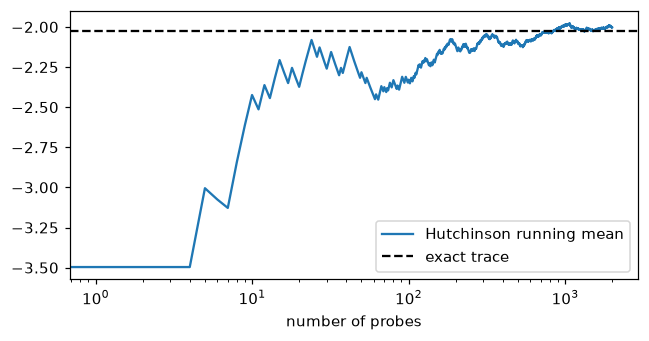

In [20]:
def exact_trace(f, t, y):
    return jnp.trace(jax.jacfwd(lambda y: f(t, y, None))(y))


def hutchinson_trace(f, t, y, eps):
    _, jv = jax.jvp(lambda y: f(t, y, None), (y,), (eps,))
    return eps @ jv


key, k_probe = jr.split(key)
y_probe = x_moons[0]
eps = jr.rademacher(k_probe, (2000, 2), dtype=jnp.float32)
exact = exact_trace(cnf.func, 0.5, y_probe)
estimates = jax.vmap(lambda e: hutchinson_trace(cnf.func, 0.5, y_probe, e))(eps)
running = jnp.cumsum(estimates) / jnp.arange(1, eps.shape[0] + 1)

plt.figure(figsize=(6, 3.2))
plt.plot(running, label="Hutchinson running mean")
plt.axhline(float(exact), color="k", ls="--", label="exact trace")
plt.xscale("log"); plt.xlabel("number of probes"); plt.legend(); plt.tight_layout(); plt.show()

## Where to go next

- **Read** Kidger's [*On Neural Differential Equations*](https://arxiv.org/abs/2202.02435) for the full story, including Neural CDEs (for irregular time series) and Neural SDEs.
- **Diffrax examples**: [Neural CDE](https://docs.kidger.site/diffrax/examples/neural_cde/), [Neural SDE](https://docs.kidger.site/diffrax/examples/neural_sde/), [latent ODE](https://docs.kidger.site/diffrax/examples/latent_ode/) (the time-series model from the original paper).
- **Augmented Neural ODEs** ([Dupont et al. 2019](https://arxiv.org/abs/1904.01681)): add extra dimensions so that trajectories can "go around" each other. Try classifying two concentric circles with `NeuralODE` above and watch it struggle.
- **Regularizing the dynamics** ([Finlay et al. 2020](https://arxiv.org/abs/2002.02798)): penalize kinetic energy and Jacobian norm so the learned ODE is cheap to solve. Section 2's step counts are the metric to watch.
- The original PyTorch implementation, [torchdiffeq](https://github.com/rtqichen/torchdiffeq), and its CNF/FFJORD code, [ffjord](https://github.com/rtqichen/ffjord).